<a href="https://sigmoidal.ai">
  <img src="https://raw.githubusercontent.com/carlosfab/blog-sigmoidal/main/_assets/logo_sigmoidal.png" alt="Sigmoidal" width="300">
</a>

# Transfer Learning with PyTorch

**Author:** Carlos Melo — [sigmoidal.ai](https://sigmoidal.ai)

## Loading Oxford Flowers 102

We will use the Oxford Flowers 102 dataset, which contains images of 102 flower species. With only 1,020 training images, it is an ideal scenario for transfer learning.

In [1]:
import json
import urllib.request

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Reproducibility
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


ResNet18 expects 224x224 images. We apply data augmentation during training and only resizing during testing.

In [2]:
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [3]:
train_dataset = torchvision.datasets.Flowers102(
    root="./data", split="train", download=True, transform=train_transform
)

val_dataset = torchvision.datasets.Flowers102(
    root="./data", split="val", download=True, transform=test_transform
)

test_dataset = torchvision.datasets.Flowers102(
    root="./data", split="test", download=True, transform=test_transform
)

print("Training:", len(train_dataset), "imagens")
print("Validation:", len(val_dataset), "imagens")
print("Test:", len(test_dataset), "imagens")

100%|██████████| 345M/345M [00:20<00:00, 16.6MB/s]
100%|██████████| 502/502 [00:00<00:00, 1.85MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 46.6MB/s]


Treino: 1020 imagens
Validacao: 1020 imagens
Teste: 6149 imagens


In [4]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

Let's visualize some images from the dataset by denormalizing with the ImageNet mean and standard deviation.

In [5]:
def denormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img * std + mean
    img = torch.clamp(img, 0, 1)
    return img

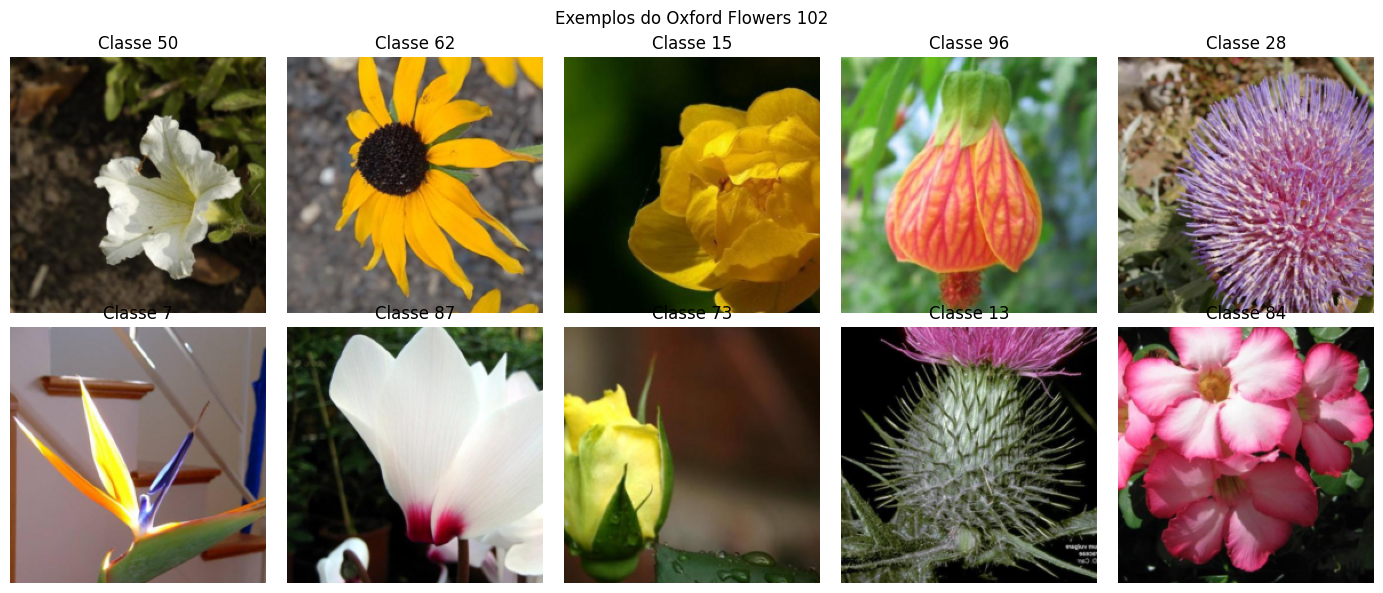

In [6]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    img = denormalize(images[i])
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(f"Classe {labels[i].item()}")
    ax.axis("off")
plt.suptitle("Oxford Flowers 102 Samples")
plt.tight_layout()
plt.show()

## Exploring ResNet18

ResNet18 is an 18-layer network with residual connections, pre-trained on ImageNet (1,000 classes). Let's load it and understand its structure before adapting it.

In [7]:
model_original = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model_original.eval()

print(model_original)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 201MB/s]

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

The backbone extracts features and the `fc` layer classifies. Let's inspect the main components.

In [8]:
# Initial layer
print("Input: Conv2d + BN + ReLU + MaxPool")
print(model_original.conv1)
print(model_original.bn1)
print()

# Residual blocks
print("Block layer1:", model_original.layer1)
print()

# Classification head
print("Average Pool:", model_original.avgpool)
print("FC (classifier):", model_original.fc)
print(f"  Input: {model_original.fc.in_features} features")
print(f"  Output: {model_original.fc.out_features} classes (ImageNet)")

Entrada: Conv2d + BN + ReLU + MaxPool
Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

Bloco layer1: Sequential(
  (0): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (1): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05,

Before adapting the network, let's see how it classifies a flower using the 1,000 ImageNet classes.

In [9]:
# Download ImageNet class names
url = "https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json"
urllib.request.urlretrieve(url, "imagenet_labels.json")

with open("imagenet_labels.json") as f:
    imagenet_labels = json.load(f)

print(f"Total de classes ImageNet: {len(imagenet_labels)}")
print("First 5:", imagenet_labels[:5])

Total de classes ImageNet: 1000
Primeiras 5: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead shark']


Predicoes da ResNet18 (ImageNet) para uma flor:

                           daisy: 69.2%
                             pot: 6.4%
                             bee: 5.1%
                            vase: 5.0%
                     small white: 2.3%


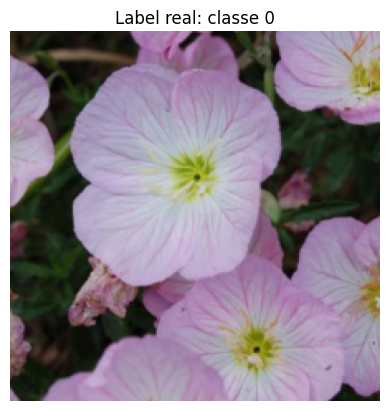

In [10]:
# Get a flower image directly from the dataset (fixed index for reproducibility)
img, label = train_dataset[0]

model_original = model_original.to(device)
img_gpu = img.unsqueeze(0).to(device)

with torch.no_grad():
    output = model_original(img_gpu)
    probs = torch.softmax(output, dim=1)
    top5_probs, top5_idx = probs.topk(5)

print("ResNet18 (ImageNet) predictions for a flower:")
print()
for i in range(5):
    idx = top5_idx[0][i].item()
    prob = top5_probs[0][i].item()
    print(f"  {imagenet_labels[idx]:>30s}: {prob:.1%}")

plt.imshow(denormalize(img).permute(1, 2, 0).numpy())
plt.title(f"True label: class {label}")
plt.axis("off")
plt.show()

## Feature Extraction

We freeze the entire backbone and train only a new classification layer. The backbone works as a fixed feature extractor.

In [11]:
model_fe = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

# Freeze all backbone parameters
for param in model_fe.parameters():
    param.requires_grad = False

# Replace the fc layer for 102 classes
# (new modules are created with requires_grad=True by default)
num_features = model_fe.fc.in_features
model_fe.fc = nn.Linear(num_features, 102)

# Only the new fc has gradients
print("Trainable parameters:")
for name, param in model_fe.named_parameters():
    if param.requires_grad:
        print(f"  {name}: {param.shape}")

total = sum(p.numel() for p in model_fe.parameters())
trainable = sum(p.numel() for p in model_fe.parameters() if p.requires_grad)
print(f"\nTotal: {total:,} | Trainable: {trainable:,} ({100*trainable/total:.1f}%)")

model_fe = model_fe.to(device)

Parametros treinaveis:
  fc.weight: torch.Size([102, 512])
  fc.bias: torch.Size([102])

Total: 11,228,838 | Treinaveis: 52,326 (0.5%)


Generic training function that we will reuse in both experiments. It returns training and validation losses, as well as validation accuracy per epoch.

In [12]:
def treinar(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    train_losses = []
    val_losses = []
    val_accuracies = []

    for epoch in range(num_epochs):
        # Training
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)

        # Validation
        model.eval()
        correct = 0
        total = 0
        val_running_loss = 0.0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader)
        val_losses.append(val_loss)
        val_acc = 100 * correct / total
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f} - Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.1f}%")

    return train_losses, val_losses, val_accuracies

In [13]:
criterion = nn.CrossEntropyLoss()
optimizer_fe = optim.Adam(model_fe.fc.parameters(), lr=0.001)

print("Training with feature extraction (frozen backbone)")
print()
fe_losses, fe_val_losses, fe_accs = treinar(model_fe, train_loader, val_loader, criterion, optimizer_fe, num_epochs=15)

Treinando com feature extraction (backbone congelado)

Epoca 1/15 - Loss: 4.6376 - Val Loss: 3.9180 - Val Acc: 14.7%
Epoca 2/15 - Loss: 3.3650 - Val Loss: 2.9599 - Val Acc: 51.1%
Epoca 3/15 - Loss: 2.4418 - Val Loss: 2.2943 - Val Acc: 63.8%
Epoca 4/15 - Loss: 1.7949 - Val Loss: 1.8449 - Val Acc: 73.3%
Epoca 5/15 - Loss: 1.3424 - Val Loss: 1.5473 - Val Acc: 78.7%
Epoca 6/15 - Loss: 1.0660 - Val Loss: 1.3592 - Val Acc: 81.3%
Epoca 7/15 - Loss: 0.8356 - Val Loss: 1.2024 - Val Acc: 81.7%
Epoca 8/15 - Loss: 0.7104 - Val Loss: 1.0846 - Val Acc: 81.8%
Epoca 9/15 - Loss: 0.6006 - Val Loss: 0.9971 - Val Acc: 83.3%
Epoca 10/15 - Loss: 0.4900 - Val Loss: 0.9400 - Val Acc: 83.4%
Epoca 11/15 - Loss: 0.4276 - Val Loss: 0.8799 - Val Acc: 84.4%
Epoca 12/15 - Loss: 0.3843 - Val Loss: 0.8261 - Val Acc: 84.8%
Epoca 13/15 - Loss: 0.3287 - Val Loss: 0.7939 - Val Acc: 84.7%
Epoca 14/15 - Loss: 0.2928 - Val Loss: 0.7765 - Val Acc: 85.7%
Epoca 15/15 - Loss: 0.2577 - Val Loss: 0.7367 - Val Acc: 85.7%


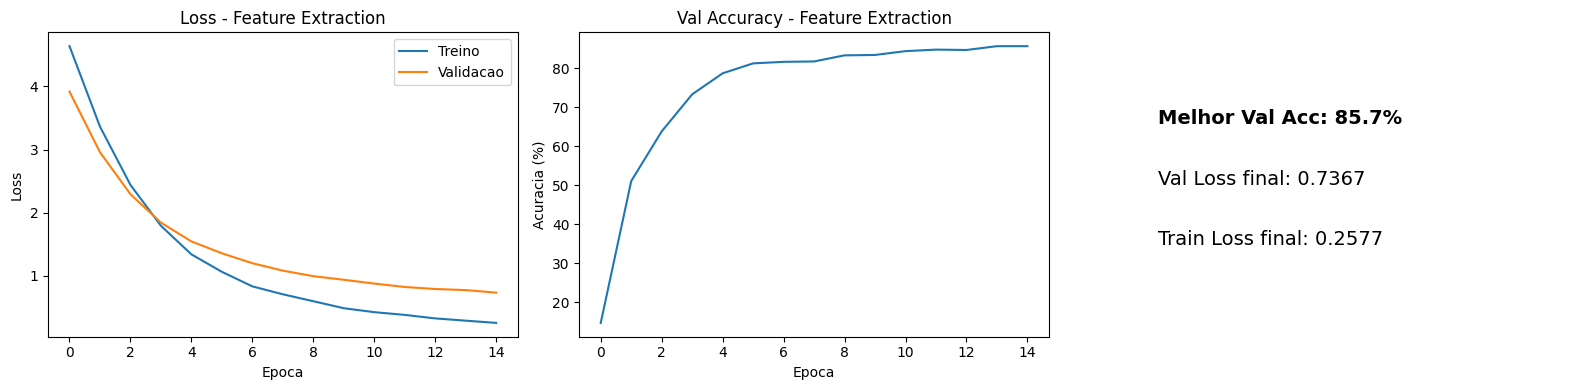

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(fe_losses, label="Training")
axes[0].plot(fe_val_losses, label="Validation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss - Feature Extraction")
axes[0].legend()

axes[1].plot(fe_accs)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Val Accuracy - Feature Extraction")

axes[2].axis("off")
axes[2].text(0.1, 0.7, f"Best Val Acc: {max(fe_accs):.1f}%", fontsize=14, fontweight="bold")
axes[2].text(0.1, 0.5, f"Final Val Loss: {fe_val_losses[-1]:.4f}", fontsize=14)
axes[2].text(0.1, 0.3, f"Final Train Loss: {fe_losses[-1]:.4f}", fontsize=14)

plt.tight_layout()
plt.show()

Let's evaluate the feature extraction model on the test set for a complete comparison with fine-tuning.

In [15]:
model_fe.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_fe(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_acc_fe = 100 * correct / total
print(f"Test accuracy (Feature Extraction): {test_acc_fe:.1f}%")

Acuracia no teste (Feature Extraction): 83.7%


## Fine-Tuning

Now we unfreeze `layer4` (the last residual block) and train it along with the head, using differential learning rates to avoid destroying the pre-trained weights.

The new `fc` layer does not need an explicit `requires_grad = True` — modules created after freezing are already trainable by default in PyTorch.

In [16]:
model_ft = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

# Freeze everything first
for param in model_ft.parameters():
    param.requires_grad = False

# Unfreeze layer4
for param in model_ft.layer4.parameters():
    param.requires_grad = True

# Replace fc (new modules are created with requires_grad=True)
model_ft.fc = nn.Linear(model_ft.fc.in_features, 102)

# Check what is trainable
total_params = sum(p.numel() for p in model_ft.parameters())
trainable_params = sum(p.numel() for p in model_ft.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Trainable percentage: {100*trainable_params/total_params:.1f}%")

model_ft = model_ft.to(device)

Parametros totais: 11,228,838
Parametros treinaveis: 8,446,054
Percentual treinavel: 75.2%


Lower learning rate for the backbone (already good weights) and higher for the new head.

In [17]:
optimizer_ft = optim.Adam([
    {"params": model_ft.layer4.parameters(), "lr": 1e-4},
    {"params": model_ft.fc.parameters(), "lr": 1e-3},
])

print("Training with fine-tuning (layer4 + fc)")
print()
ft_losses, ft_val_losses, ft_accs = treinar(model_ft, train_loader, val_loader, criterion, optimizer_ft, num_epochs=15)

Treinando com fine-tuning (layer4 + fc)

Epoca 1/15 - Loss: 4.1121 - Val Loss: 2.6128 - Val Acc: 56.1%
Epoca 2/15 - Loss: 1.8260 - Val Loss: 1.3536 - Val Acc: 78.1%
Epoca 3/15 - Loss: 0.8362 - Val Loss: 0.8890 - Val Acc: 86.1%
Epoca 4/15 - Loss: 0.4232 - Val Loss: 0.6834 - Val Acc: 88.7%
Epoca 5/15 - Loss: 0.2432 - Val Loss: 0.5751 - Val Acc: 90.7%
Epoca 6/15 - Loss: 0.1523 - Val Loss: 0.4948 - Val Acc: 90.9%
Epoca 7/15 - Loss: 0.0948 - Val Loss: 0.4687 - Val Acc: 90.5%
Epoca 8/15 - Loss: 0.0638 - Val Loss: 0.4282 - Val Acc: 91.1%
Epoca 9/15 - Loss: 0.0510 - Val Loss: 0.4131 - Val Acc: 91.6%
Epoca 10/15 - Loss: 0.0411 - Val Loss: 0.4020 - Val Acc: 91.5%
Epoca 11/15 - Loss: 0.0346 - Val Loss: 0.3811 - Val Acc: 91.6%
Epoca 12/15 - Loss: 0.0289 - Val Loss: 0.3772 - Val Acc: 91.9%
Epoca 13/15 - Loss: 0.0262 - Val Loss: 0.3580 - Val Acc: 92.3%
Epoca 14/15 - Loss: 0.0236 - Val Loss: 0.3613 - Val Acc: 91.8%
Epoca 15/15 - Loss: 0.0201 - Val Loss: 0.3378 - Val Acc: 92.5%


### Comparing Both Approaches

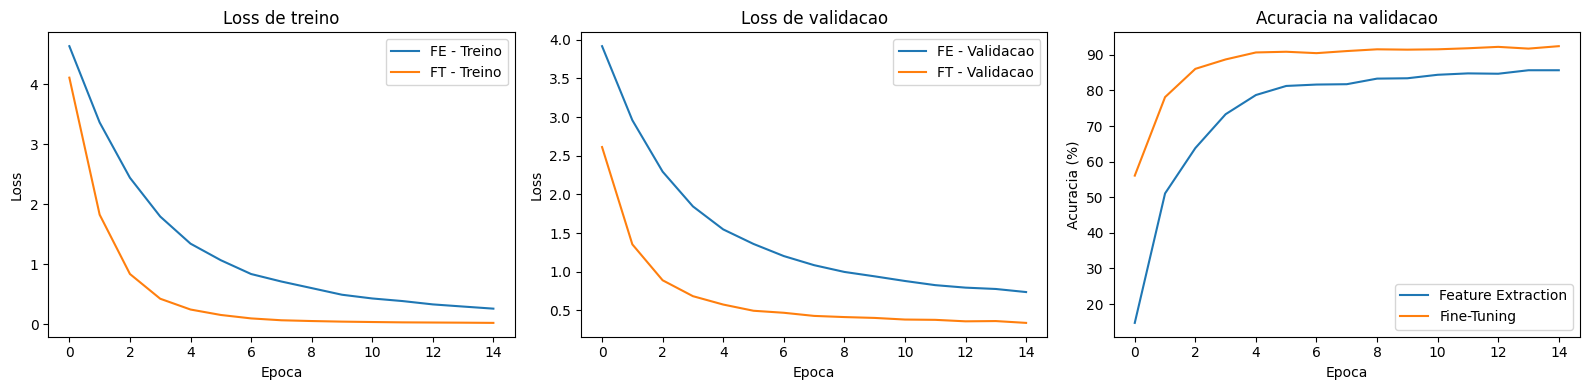

Melhor acuracia Feature Extraction: 85.7%
Melhor acuracia Fine-Tuning: 92.5%


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(fe_losses, label="FE - Training")
axes[0].plot(ft_losses, label="FT - Training")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss")
axes[0].legend()

axes[1].plot(fe_val_losses, label="FE - Validation")
axes[1].plot(ft_val_losses, label="FT - Validation")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Validation Loss")
axes[1].legend()

axes[2].plot(fe_accs, label="Feature Extraction")
axes[2].plot(ft_accs, label="Fine-Tuning")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Accuracy (%)")
axes[2].set_title("Validation Accuracy")
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Best accuracy Feature Extraction: {max(fe_accs):.1f}%")
print(f"Best accuracy Fine-Tuning: {max(ft_accs):.1f}%")

### Test Set Accuracy

In [19]:
model_ft.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_ft(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_acc_ft = 100 * correct / total
print(f"Test accuracy (Fine-Tuning): {test_acc_ft:.1f}%")
print(f"Test accuracy (Feature Extraction): {test_acc_fe:.1f}%")
print()
print("=" * 55)
print(f"{'Metric':<25s} {'FE':>12s} {'FT':>12s}")
print("-" * 55)
print(f"{'Val Acc (best)':<25s} {max(fe_accs):>11.1f}% {max(ft_accs):>11.1f}%")
print(f"{'Test Acc':<25s} {test_acc_fe:>11.1f}% {test_acc_ft:>11.1f}%")
print(f"{'Val Loss (final)':<25s} {fe_val_losses[-1]:>12.4f} {ft_val_losses[-1]:>12.4f}")
print(f"{'Train Loss (final)':<25s} {fe_losses[-1]:>12.4f} {ft_losses[-1]:>12.4f}")
print("=" * 55)

Acuracia no teste (Fine-Tuning): 90.2%
Acuracia no teste (Feature Extraction): 83.7%

Metrica                             FE           FT
-------------------------------------------------------
Val Acc (melhor)                 85.7%        92.5%
Test Acc                         83.7%        90.2%
Val Loss (final)                0.7367       0.3378
Train Loss (final)              0.2577       0.0201
